# Simulate and Plot Ventilator Waveforms with Bellows

This notebook uses `bellows` as a Python library. It focuses on simulation setup, waveform plotting, pressure-volume loops, and comparing scenarios.

Run it from the repository root with the editable package installed, or select a kernel where `bellows` is installed.

In [1]:
%load_ext autoreload
%autoreload 2

from dataclasses import replace

import matplotlib.pyplot as plt

from bellows import (
    LinearLung,
    PatientMechanics,
    SimulationRecorder,
    SimulationRun,
    VenegasLung,
    VentilationSimulation,
    VentilatorSettings,
)


## Small Plotting Helpers

In [2]:
def run_case(settings, patient, *, seconds=12.0, dt_s=0.01):
    simulation = VentilationSimulation(settings=settings, patient=patient)
    run = simulation.run(seconds=seconds, dt_s=dt_s)
    return simulation, run


def plot_waveforms(run, *, title):
    time_s = run.column("time_s")

    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7))
    axes[0].plot(time_s, run.column("pressure_cm_h2o"), color="tab:orange")
    axes[0].set_ylabel("Pressure\ncmH2O")
    axes[1].plot(time_s, run.column("flow_l_min"), color="tab:blue")
    axes[1].axhline(0, color="0.8", linewidth=0.8)
    axes[1].set_ylabel("Flow\nL/min")
    axes[2].plot(time_s, run.column("volume_ml"), color="tab:green")
    axes[2].set_ylabel("Volume\nmL")
    axes[2].set_xlabel("Time, s")

    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes


def plot_pv_loop(run, *, breath=None, title="Pressure-volume loop"):
    breath_run = run.last_completed_breath() if breath is None else run.breath(breath)
    inspiration = SimulationRun(
        sample for sample in breath_run if sample.phase == "inspiration"
    )
    expiration = SimulationRun(
        sample for sample in breath_run if sample.phase == "expiration"
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(
        inspiration.column("volume_ml"),
        inspiration.column("pressure_cm_h2o"),
        label="inspiration",
    )
    ax.plot(
        expiration.column("volume_ml"),
        expiration.column("pressure_cm_h2o"),
        label="expiration",
    )
    ax.set_xlabel("Volume, mL")
    ax.set_ylabel("Airway pressure, cmH2O")
    ax.set_title(f"{title} (breath {breath_run[0].breath})")
    ax.legend()
    ax.grid(True, alpha=0.25)
    return fig, ax


## Build and Run a Pressure-Control Case

The simulation is just Python objects: settings, patient mechanics, and a `VentilationSimulation`.

In [3]:
settings = VentilatorSettings(
    mode="PCV",
    rr_bpm=16.0,
    pinsp_cm_h2o=18.0,
    peep_cm_h2o=6,
    ie_i=1.0,
    ie_e=2.0,
)

patient = PatientMechanics(
    lung_model=LinearLung(compliance_l_per_cm_h2o=0.035),
    resistance_cm_h2o_s_per_l=12.0,
    etco2_kpa=5.4,
)

simulation, run = run_case(settings, patient, seconds=12.0)
len(run), run.last_breath_summary


(1201,
 BreathSummary(breath=2, start_time_s=7.519999999999883, end_time_s=11.259999999999804, min_volume_l=0.21524122959072406, max_volume_l=0.8060483744184059, peak_pressure_cm_h2o=23.999999999999954, etco2_kpa=5.4))

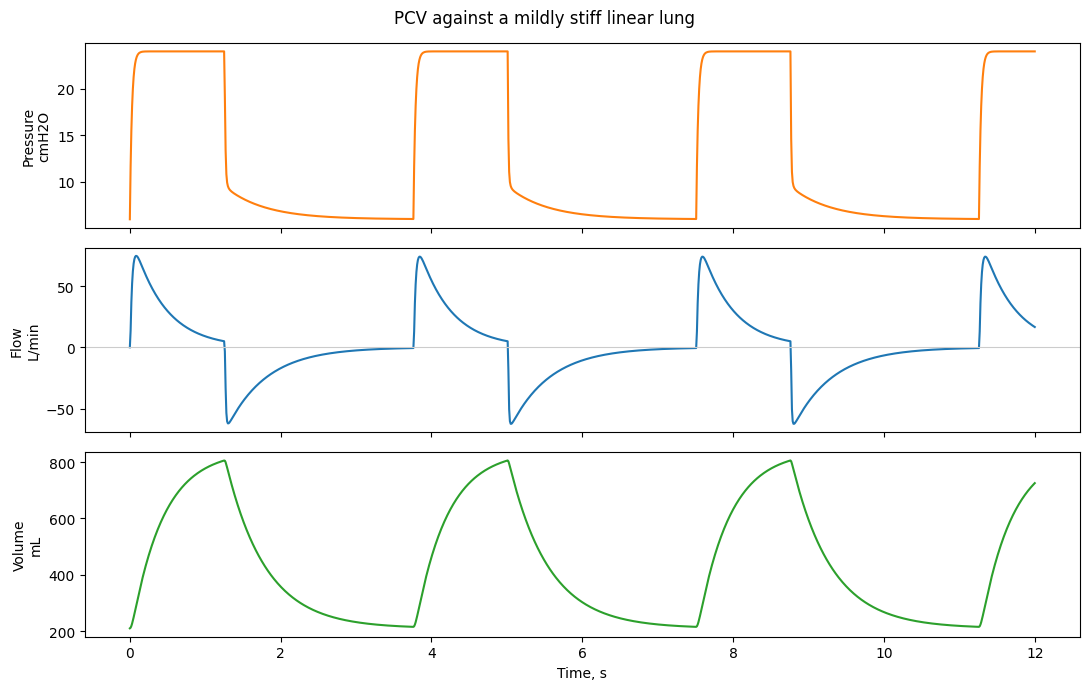

In [4]:
plot_waveforms(run, title="PCV against a mildly stiff linear lung");


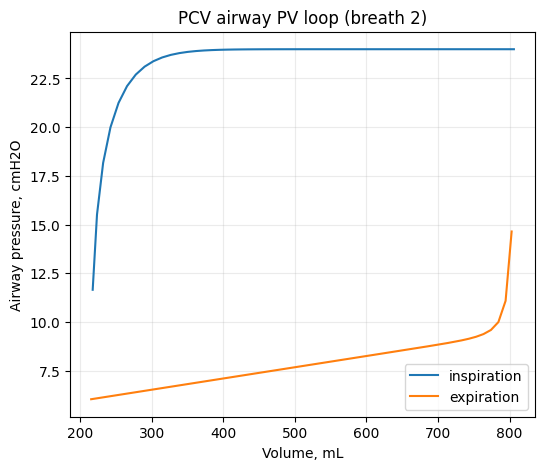

In [5]:
plot_pv_loop(run, title="PCV airway PV loop");


## Compare Patient Mechanics

Here the ventilator settings stay fixed while the patient model changes. A stiffer lung should produce lower volume for the same pressure target.

In [6]:
normal_patient = PatientMechanics(lung_model=LinearLung(0.05), resistance_cm_h2o_s_per_l=10.0)
stiff_patient = PatientMechanics(lung_model=LinearLung(0.025), resistance_cm_h2o_s_per_l=10.0)

normal_sim, normal_run = run_case(settings, normal_patient, seconds=12.0)
stiff_sim, stiff_run = run_case(settings, stiff_patient, seconds=12.0)

normal_summary = normal_run.last_breath_summary
stiff_summary = stiff_run.last_breath_summary

{
    "normal_vt_ml": normal_summary.vt_ml,
    "normal_peak_pressure": normal_summary.peak_pressure_cm_h2o,
    "stiff_vt_ml": stiff_summary.vt_ml,
    "stiff_peak_pressure": stiff_summary.peak_pressure_cm_h2o,
}


{'normal_vt_ml': 805.5592366580923,
 'normal_peak_pressure': 23.999999999999954,
 'stiff_vt_ml': 446.4182748981377,
 'stiff_peak_pressure': 23.999999999999954}

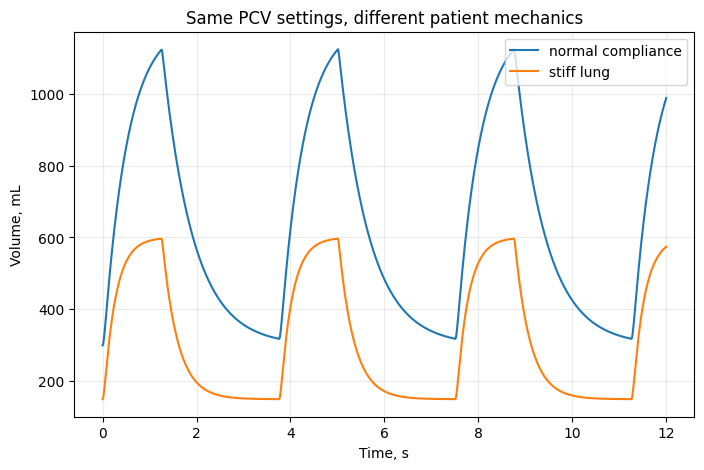

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(normal_run.column("time_s"), normal_run.column("volume_ml"), label="normal compliance")
ax.plot(stiff_run.column("time_s"), stiff_run.column("volume_ml"), label="stiff lung")
ax.set_xlabel("Time, s")
ax.set_ylabel("Volume, mL")
ax.set_title("Same PCV settings, different patient mechanics")
ax.legend()
ax.grid(True, alpha=0.25);


## Compare a Recruitable Lung at Different PEEP

The Venegas model has a nonlinear pressure-volume curve. Raising PEEP can move the lung onto a different part of that curve.

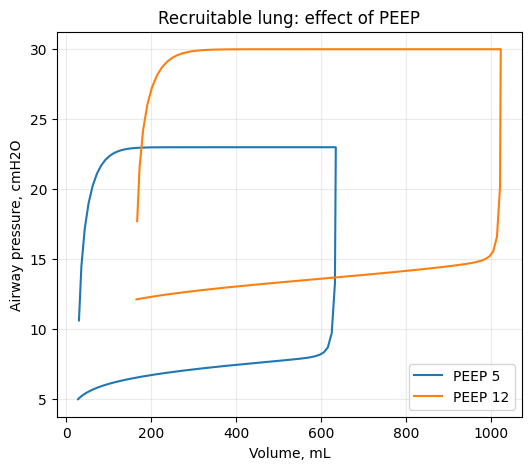

In [8]:
recruitable_patient = PatientMechanics(
    lung_model=VenegasLung(
        inflection_cm_h2o=20.0,
        slope_width_cm_h2o=4.0,
        recruitable_volume_l=1.2,
    ),
    resistance_cm_h2o_s_per_l=12.0,
)

low_peep_settings = replace(settings, peep_cm_h2o=5.0)
higher_peep_settings = replace(settings, peep_cm_h2o=12.0)

_low_sim, low_peep_run = run_case(low_peep_settings, recruitable_patient, seconds=12.0)
_high_sim, higher_peep_run = run_case(higher_peep_settings, recruitable_patient, seconds=12.0)

fig, ax = plt.subplots(figsize=(6, 5))
low_loop = low_peep_run.last_completed_breath()
high_loop = higher_peep_run.last_completed_breath()
ax.plot(low_loop.column("volume_ml"), low_loop.column("pressure_cm_h2o"), label="PEEP 5")
ax.plot(high_loop.column("volume_ml"), high_loop.column("pressure_cm_h2o"), label="PEEP 12")
ax.set_xlabel("Volume, mL")
ax.set_ylabel("Airway pressure, cmH2O")
ax.set_title("Recruitable lung: effect of PEEP")
ax.legend()
ax.grid(True, alpha=0.25);


## Queue a Settings Change During a Run

The simulator applies ventilator setting changes at a breath boundary. `sim.run(...)` advances relative to the current simulation time, `update_settings(...)` queues ventilator changes by default, and `SimulationRecorder` can collect samples across multiple run segments.


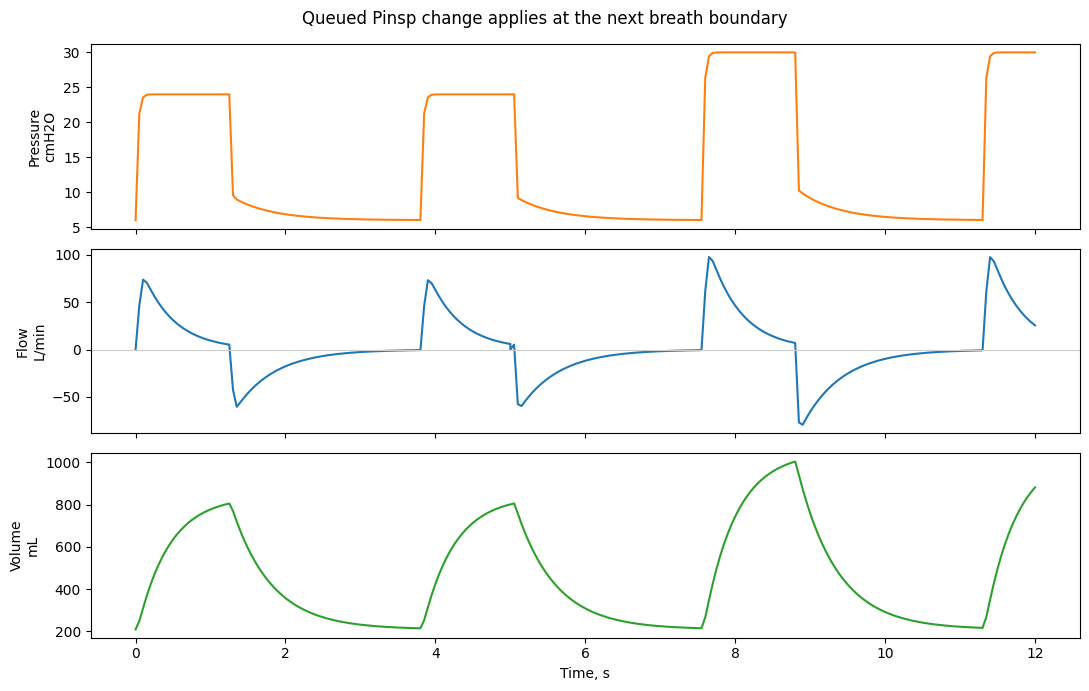

In [9]:
changing_sim = VentilationSimulation(settings=settings, patient=patient)
recorder = SimulationRecorder()

recorder.record(changing_sim.run(seconds=5.0, dt_s=0.05))
changing_sim.update_settings(pinsp_cm_h2o=24.0)
recorder.record(changing_sim.run(seconds=7.0, dt_s=0.05))

changing_run = recorder.to_run(breath_summaries=changing_sim.breath_history)
plot_waveforms(changing_run, title="Queued Pinsp change applies at the next breath boundary");
